Componentes: Irene Alavés, Claudia Fernández, Eva Graña y Blanca Xifra

# 1. Preparación del entorno y carga del dataset

## 1.1 Instalaciones

In [ ]:
!pip install -q ucimlrepo shap scikit-learn pandas numpy matplotlib seaborn

## 1.2 Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
sns.set_context("notebook")

## 1.3 Cargar dataset Diabetes 130-US Hospitals desde UCI

In [ ]:
diabetes = fetch_ucirepo(id=296)

X = diabetes.data.features.copy()
y = diabetes.data.targets.copy()

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Dimensión de X: (101766, 47)
Dimensión de y: (101766, 1)


## 1.4 Descripción del dataset


In [ ]:
print("Primeras filas de X:")
display(X.head())

print("\nPrimeras filas de y:")
display(y.head())

print("\nTipos de datos:")
display(X.dtypes)

print("\nValores nulos por columna:")
display(X.isnull().sum().sort_values(ascending=False).head(20))

Primeras filas de X:


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes



Primeras filas de y:


,readmitted
0,NO
1,>30
2,NO
3,NO
4,NO



Tipos de datos:


,0
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64
payer_code,object
medical_specialty,object



Valores nulos por columna:


,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
time_in_hospital,0


## 1.5 Variable objetivo

In [ ]:
print("Columnas objetivo:")
print(y.columns)

for col in y.columns:
    print(f"\nDistribución de {col}:")
    print(y[col].value_counts(dropna=False))

Columnas objetivo:
Index(['readmitted'], dtype='object')

Distribución de readmitted:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


# 2. Inspeccionar los datos y entender la variable objetivo

## 2.1 Crear un único dataframe y definir el target binario

In [ ]:
# Copiamos las features y añadimos la variable objetivo original
df = X.copy()
df["readmitted"] = y["readmitted"]

# Definimos el target binario:
# 1 -> readmisión en menos de 30 días
# 0 -> resto de casos
df["readmitted_binary"] = (df["readmitted"] == "<30").astype(int)

print("Dimensión del dataset completo:", df.shape)
print("\nDistribución de la variable objetivo original:")
print(df["readmitted"].value_counts(dropna=False))

print("\nDistribución del target binario:")
print(df["readmitted_binary"].value_counts(dropna=False))

print("\nPorcentaje del target binario:")
print((df["readmitted_binary"].value_counts(normalize=True) * 100).round(2))

Dimensión del dataset completo: (101766, 49)

Distribución de la variable objetivo original:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Distribución del target binario:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Porcentaje del target binario:
readmitted_binary
0    88.84
1    11.16
Name: proportion, dtype: float64


## 2.2 Separación de variables numéricas y categóricas

In [ ]:
target_cols = ["readmitted", "readmitted_binary"]
feature_cols = [col for col in df.columns if col not in target_cols]

numeric_cols = df[feature_cols].select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df[feature_cols].select_dtypes(include="object").columns.tolist()

print("Número de variables numéricas:", len(numeric_cols))
print("Número de variables categóricas:", len(categorical_cols))

print("\nVariables numéricas:")
print(numeric_cols)

print("\nVariables categóricas (primeras 20):")
print(categorical_cols[:20])

Número de variables numéricas: 11
Número de variables categóricas: 36

Variables numéricas:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Variables categóricas (primeras 20):
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide']


## 2.3 Porcentaje de nulos por columna

In [ ]:
missing_ratio = df[feature_cols].isnull().mean().sort_values(ascending=False) * 100

print("Porcentaje de valores faltantes por columna:")
display(missing_ratio.round(2))

cols_over_50 = missing_ratio[missing_ratio > 50].index.tolist()

print("\nColumnas con más del 50% de nulos:")
print(cols_over_50)

Porcentaje de valores faltantes por columna:


,0
weight,96.86
max_glu_serum,94.75
A1Cresult,83.28
medical_specialty,49.08
payer_code,39.56
race,2.23
diag_3,1.40
diag_2,0.35
diag_1,0.02
time_in_hospital,0.00



Columnas con más del 50% de nulos:
['weight', 'max_glu_serum', 'A1Cresult']


# 3. EDA Inicial

## 3.1 Estadística Descriptiva

In [ ]:
# Seleccionamos las 4 numéricas principales para no saturar las gráficas
num_features_plot = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications']

print("\n--- Estadística Descriptiva (Numéricas) ---")
display(df[num_features_plot].describe())

print("\n--- Estadística Descriptiva (Categóricas) ---")
display(df[['race', 'gender', 'age']].describe())


--- Estadística Descriptiva (Numéricas) ---


,time_in_hospital,num_lab_procedures,num_procedures,num_medications
count,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844
std,2.985108,19.674362,1.705807,8.127566
min,1.000000,1.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000
50%,4.000000,44.000000,1.000000,15.000000
75%,6.000000,57.000000,2.000000,20.000000
max,14.000000,132.000000,6.000000,81.000000



--- Estadística Descriptiva (Categóricas) ---


,race,gender,age
count,99493,101766,101766
unique,5,3,10
top,Caucasian,Female,[70-80)
freq,76099,54708,26068


## 3.2 Distribuciones Univariadas

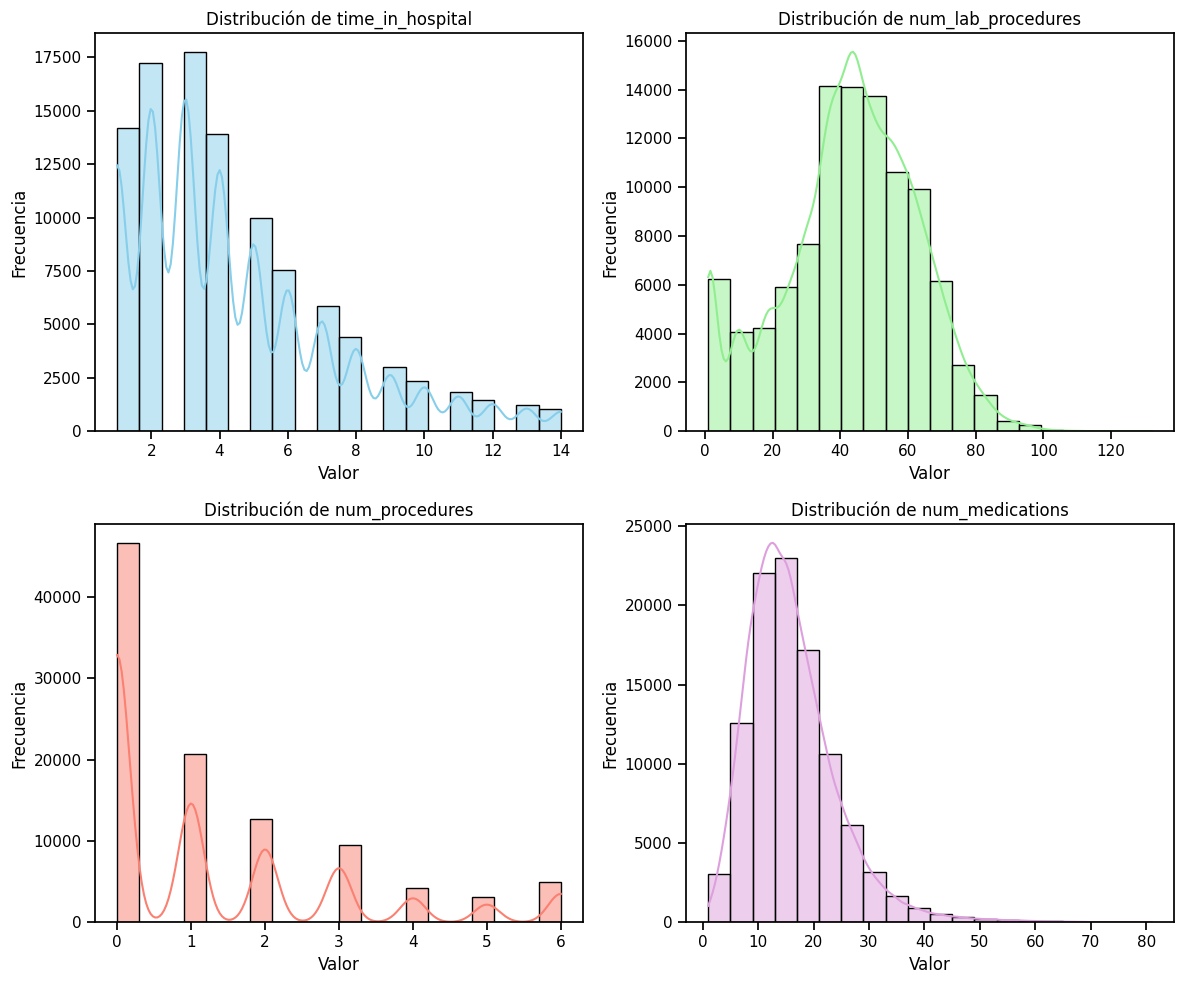

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = ['skyblue', 'lightgreen', 'salmon', 'plum']

for idx, feature in enumerate(num_features_plot):
    ax = axes[idx // 2, idx % 2]
    sns.histplot(data=df, x=feature, kde=True, bins=20, ax=ax, color=colors[idx])
    ax.set_title(f'Distribución de {feature}')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 3.3 Box Plots

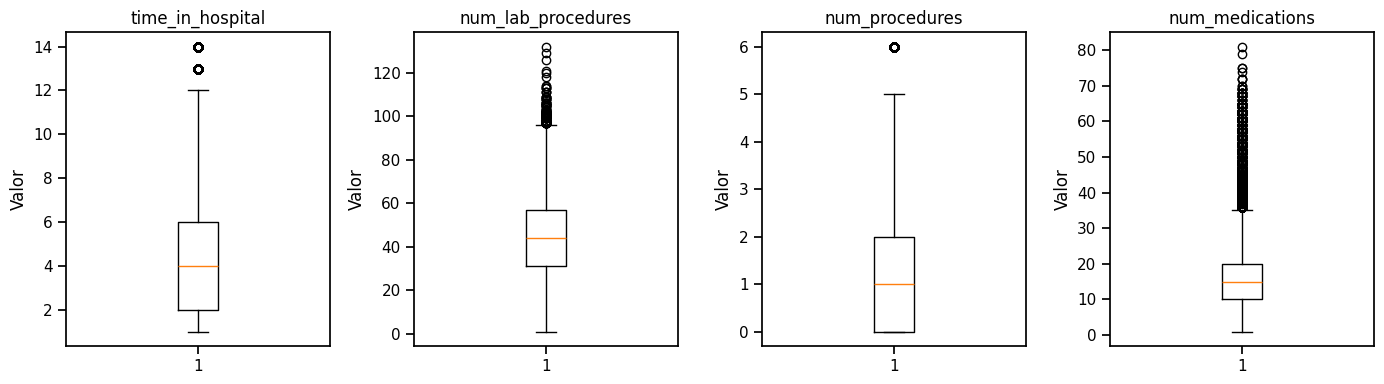

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for idx, feature in enumerate(num_features_plot):
    # Usamos dropna() por si hubiese algún nulo al graficar
    axes[idx].boxplot(df[feature].dropna())
    axes[idx].set_title(feature)
    axes[idx].set_ylabel('Valor')

plt.tight_layout()
plt.show()

## 3.4 Relaciones Bivariadas (Correlación)

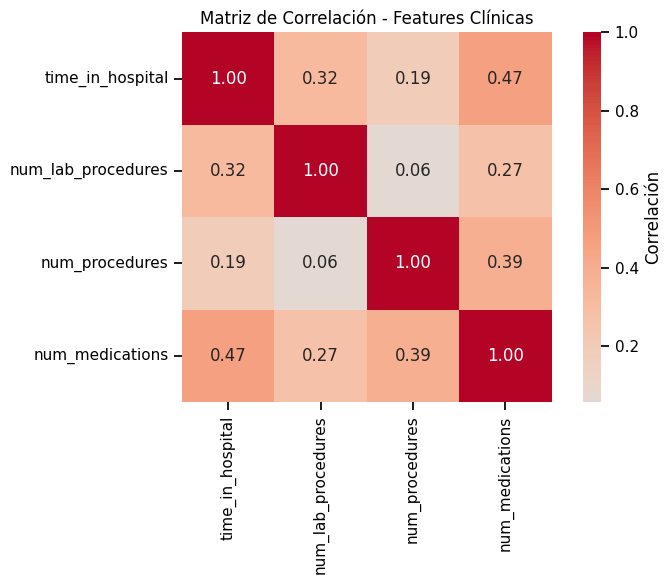

In [ ]:
# Matriz de correlación usando las variables para plotear
corr_matrix = df[num_features_plot].corr()

# Visualización
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, cbar_kws={'label': 'Correlación'})
ax.set_title('Matriz de Correlación - Features Clínicas')
plt.tight_layout()
plt.show()

## 3.5 Scatter Plots

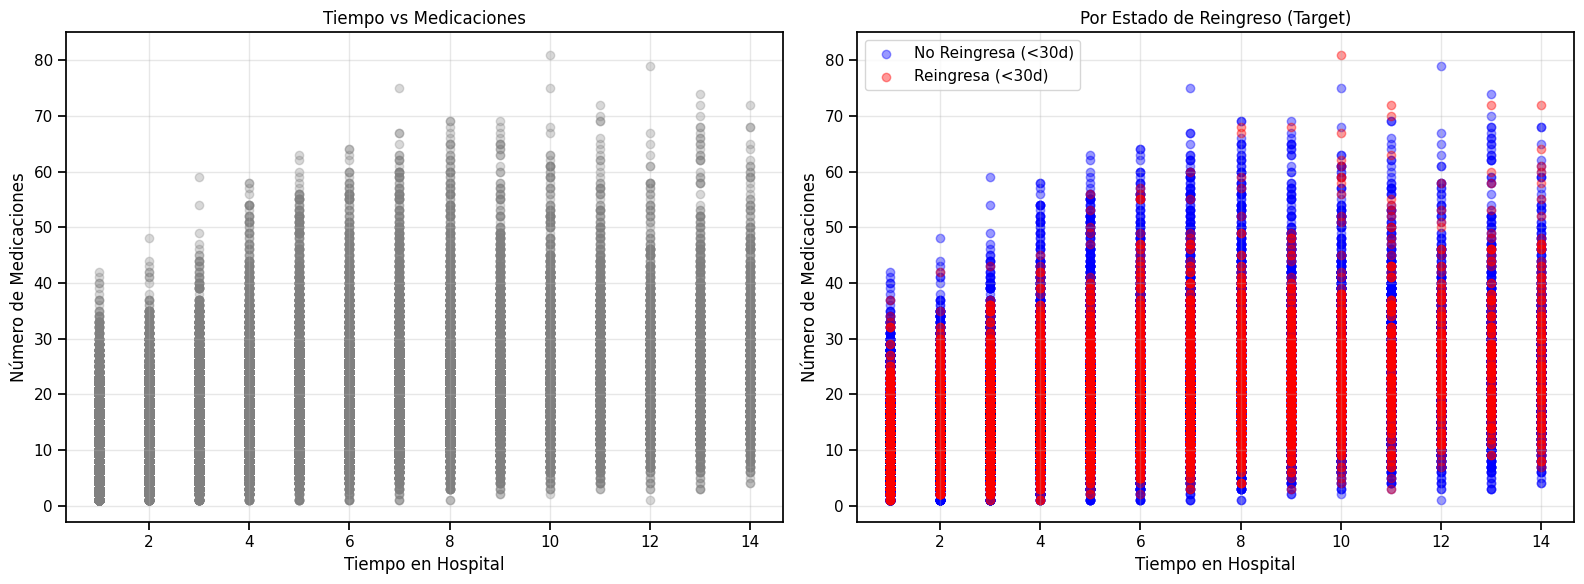

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['time_in_hospital'], df['num_medications'], alpha=0.3, color='grey')
axes[0].set_xlabel('Tiempo en Hospital')
axes[0].set_ylabel('Número de Medicaciones')
axes[0].set_title('Tiempo vs Medicaciones')
axes[0].grid(True, alpha=0.3)

targets = [0, 1]
labels = ['No Reingresa (<30d)', 'Reingresa (<30d)']
colors_scatter = ['blue', 'red']

for target_val, label, color in zip(targets, labels, colors_scatter):
    mask = df['readmitted_binary'] == target_val
    axes[1].scatter(df[mask]['time_in_hospital'], df[mask]['num_medications'],
                    label=label, alpha=0.4, color=color)

axes[1].set_xlabel('Tiempo en Hospital')
axes[1].set_ylabel('Número de Medicaciones')
axes[1].set_title('Por Estado de Reingreso (Target)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.6 Multicolinealidad

In [ ]:
high_corr = corr_matrix[(corr_matrix > 0.8) & (corr_matrix < 1.0)].sum().sum()
print(f"Correlaciones problemáticas (>0.8) en variables numéricas: {high_corr}")

Correlaciones problemáticas (>0.8) en variables numéricas: 0.0


## 3.7 Imbalance y Representatividad

/tmp/ipykernel_20075/362310148.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='readmitted_binary', palette=['#1f77b4', '#ff7f0e'], ax=ax)


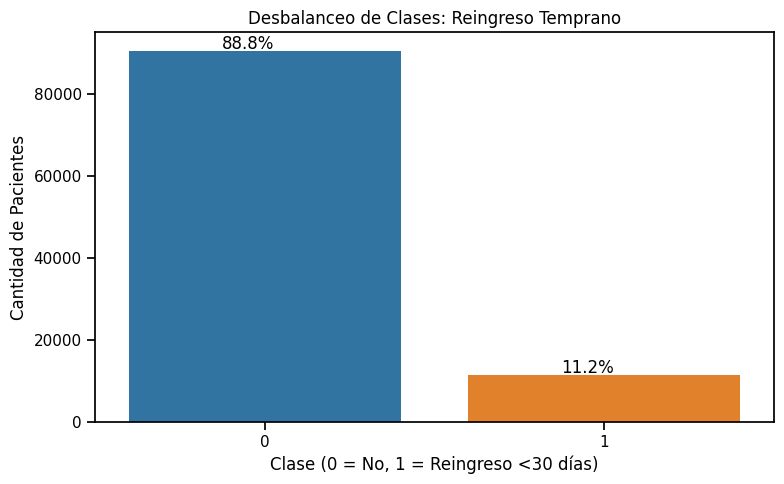

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='readmitted_binary', palette=['#1f77b4', '#ff7f0e'], ax=ax)

ax.set_title('Desbalanceo de Clases: Reingreso Temprano')
ax.set_xlabel('Clase (0 = No, 1 = Reingreso <30 días)')
ax.set_ylabel('Cantidad de Pacientes')

total = len(df['readmitted_binary'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 500
    ax.annotate(percentage, (x, y), ha='center')

plt.tight_layout()
plt.show()

## 3.8 Patrones, Anomalías e Insights (Visualización PCA)

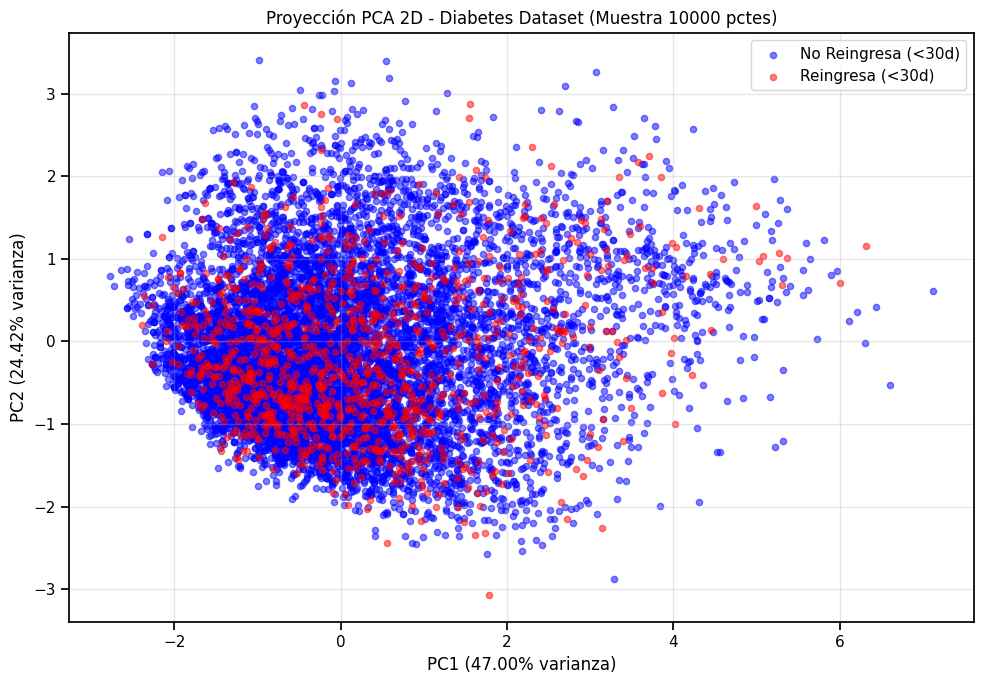

In [ ]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Rellenamos nulos numéricos y escalamos
imputer_pca = SimpleImputer(strategy='median')
scaler_pca = StandardScaler()

X_num_clean = imputer_pca.fit_transform(df[num_features_plot])
X_num_scaled = scaler_pca.fit_transform(X_num_clean)

# PCA a 2 componentes
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_num_scaled)

fig, ax = plt.subplots(figsize=(10, 7))

n_samples = 10000
for target_val, label, color in zip(targets, labels, colors_scatter):
    mask = df['readmitted_binary'][:n_samples] == target_val
    ax.scatter(X_pca[:n_samples][mask, 0], X_pca[:n_samples][mask, 1],
               label=label, s=20, alpha=0.5, color=color)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
ax.set_title(f'Proyección PCA 2D - Diabetes Dataset (Muestra {n_samples} pctes)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación del PCA

La proyección PCA muestra un solapamiento considerable entre ambas clases, lo que indica que el problema de clasificación no presenta una separación lineal simple en el espacio reducido de variables.

Esto sugiere que el modelo necesita aprender patrones complejos y combinaciones multivariantes para diferenciar pacientes con riesgo de reingreso temprano.

# 4. Metodología y Preprocesamiento

## 4.1 Limpieza de Columnas Críticas y Separación de Datos (Train-Test Split)

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Eliminar columnas con demasiados nulos y posibles variables identificadoras
cols_to_drop = cols_over_50 + ['encounter_id', 'patient_nbr']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

# 2. Variables predictoras (X) y objetivo (y)
X = df.drop(columns=cols_to_drop + ['readmitted', 'readmitted_binary'])
y = df['readmitted_binary']

# 3. Variables que aparecen como enteros, pero conceptualmente son categóricas
coded_categorical_features = [
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id'
]

# Nos aseguramos de quedarnos solo con las que existan en X
coded_categorical_features = [
    col for col in coded_categorical_features if col in X.columns
]

# Convertimos estas variables a object para que el OneHotEncoder las trate como categorías
X[coded_categorical_features] = X[coded_categorical_features].astype("object")

# 4. Definir variables numéricas reales
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 5. Definir variables categóricas reales + categóricas codificadas
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 6. Comprobación de seguridad: que no haya solapamiento entre listas
overlap = set(numeric_features).intersection(set(categorical_features))
assert len(overlap) == 0, f"Hay variables repetidas en numéricas y categóricas: {overlap}"

# 7. Train-Test Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Columnas eliminadas:")
print(cols_to_drop)

print("\nVariables categóricas codificadas tratadas como categóricas:")
print(coded_categorical_features)

print("\nNúmero de variables numéricas reales:", len(numeric_features))
print(numeric_features)

print("\nNúmero de variables categóricas:", len(categorical_features))
print(categorical_features)

print("\nDimensiones Train:", X_train.shape)
print("Dimensiones Test: ", X_test.shape)

print(f"\nReingresos en Train: {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train):.1%})")
print(f"Reingresos en Test:  {sum(y_test == 1)} ({sum(y_test == 1)/len(y_test):.1%})")

Columnas eliminadas:
['weight', 'max_glu_serum', 'A1Cresult']

Variables categóricas codificadas tratadas como categóricas:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id']

Número de variables numéricas reales: 8
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Número de variables categóricas: 36
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabe

## 4.2 Construcción del Pipeline Profesional (ColumnTransformer)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# 1. Transformer para variables numéricas
# Usamos RobustScaler por los outliers detectados en el EDA
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# 2. Transformer para variables categóricas
# Usamos One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Combinar ambos transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. Pipeline Completo: Preprocesamiento + Modelo Baseline
baseline_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=SEED))
])

## 4.3 Entrenamiento y Evaluación del Modelo Baseline

Entrenando modelo baseline (Regresión Logística)...

--- Resultados del Modelo Baseline ---
Accuracy General: 0.8882

Reporte de Clasificación:
                  precision    recall  f1-score   support

No Reingresa (0)       0.89      1.00      0.94     18083
   Reingresa (1)       0.48      0.02      0.04      2271

        accuracy                           0.89     20354
       macro avg       0.69      0.51      0.49     20354
    weighted avg       0.84      0.89      0.84     20354



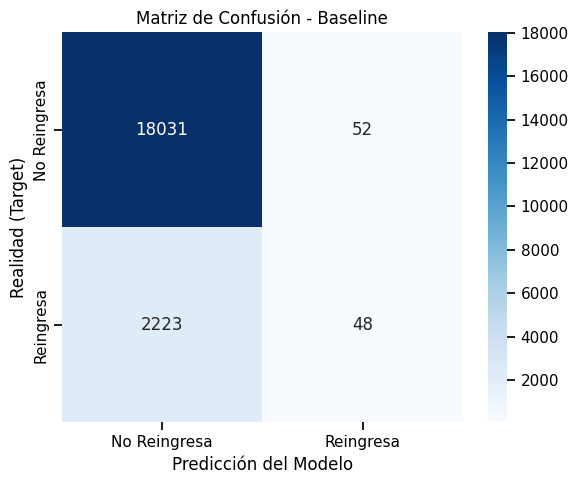

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Entrenar el Pipeline
print("Entrenando modelo baseline (Regresión Logística)...")
baseline_pipe.fit(X_train, y_train)

# Predecir sobre X_test
y_pred = baseline_pipe.predict(X_test)

# Métricas
print("\n--- Resultados del Modelo Baseline ---")
print(f"Accuracy General: {accuracy_score(y_test, y_pred):.4f}")

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['No Reingresa (0)', 'Reingresa (1)']))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Reingresa', 'Reingresa'],
            yticklabels=['No Reingresa', 'Reingresa'])
ax.set_xlabel('Predicción del Modelo')
ax.set_ylabel('Realidad (Target)')
ax.set_title('Matriz de Confusión - Baseline')
plt.tight_layout()
plt.show()

### Interpretación clínica del baseline

Aunque el modelo baseline alcanza una accuracy cercana al 89%, el recall sobre la clase positiva es extremadamente bajo (2%).

Esto significa que el clasificador apenas consigue detectar pacientes que realmente presentan reingreso temprano, limitándose en gran medida a predecir la clase mayoritaria.

Desde un punto de vista clínico, este comportamiento resulta problemático, ya que el objetivo principal del sistema es identificar pacientes vulnerables antes del alta hospitalaria.

Estos resultados justifican la necesidad de aplicar estrategias específicas para tratar el desbalanceo de clases y optimizar métricas más adecuadas para problemas médicos de riesgo.

## 4.4 Validación Cruzada

In [ ]:
from sklearn.model_selection import cross_validate

print("Calculando Validación Cruzada (5-fold)")
cv_results = cross_validate(
    baseline_pipe,
    X_train, y_train,
    cv=5,
    scoring=['accuracy', 'f1_macro'],
    n_jobs=-1
)

print(f"\nCV Accuracy: {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"CV F1 (Macro): {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")

Calculando Validación Cruzada (5-fold)

CV Accuracy: 0.8881 ± 0.0006
CV F1 (Macro): 0.4927 ± 0.0036


# 5. Comparación de modelos y tratamiento del desbalanceo

## 5.1 Función común de evaluación

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    results = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_1": precision_score(y_test, y_pred, zero_division=0),
        "recall_1": recall_score(y_test, y_pred, zero_division=0),
        "f1_1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba)
    }

    print(f"\n===== {name} =====")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["No reingresa", "Reingresa <30d"]
    ))

    cm = confusion_matrix(y_test, y_pred)
    print("Matriz de confusión:")
    print(cm)

    return results

## 5.2 Definición de modelos

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=SEED,
        class_weight="balanced"
    ))
])

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=SEED,
        class_weight="balanced",
        n_jobs=1
    ))
])

## 5.3 GridSearchCV con 5-fold CV

In [ ]:
param_grid_logreg = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 5, 10]
}

In [ ]:
grid_logreg = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid_logreg,
    cv=5,
    scoring="recall",
    n_jobs=1,
    verbose=1
)

grid_rf = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    cv=5,
    scoring="recall",
    n_jobs=1,
    verbose=1
)

In [ ]:
grid_logreg.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         ['time_in_hospital',
                                                                          'num_lab_procedures',
                                                                          'num_procedures',
                                                                          'num_medications',
                                                                          'number_outpatient',
                                                                          'number_emergency',
                                                                          'number_inpatient',
                                                                          'number_diagnoses']),
                                                                        ('cat',...
                                                                          'rosiglitazone',
                                                                          'acarbose',
                                                                          'miglitol',
                                                                          'troglitazone',
                                                                          'tolazamide',
                                                                          'examide',
                                                                          'citoglipton',
                                                                          'insulin',
                                                                          'glyburide-metformin', ...])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=1,
                                                               random_state=42))]),
             n_jobs=1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 5, 10],
                         'model__n_estimators': [100, 200]},
             scoring='recall', verbose=1)

In [ ]:
print("Mejores parámetros Logistic Regression:")
print(grid_logreg.best_params_)
print("Mejor recall CV Logistic Regression:", grid_logreg.best_score_)

print("\nMejores parámetros Random Forest:")
print(grid_rf.best_params_)
print("Mejor recall CV Random Forest:", grid_rf.best_score_)

Mejores parámetros Logistic Regression:
{'model__C': 0.1, 'model__solver': 'lbfgs'}
Mejor recall CV Logistic Regression: 0.5539292454286706

Mejores parámetros Random Forest:
{'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__n_estimators': 100}
Mejor recall CV Random Forest: 0.5933329216245784


## 5.4 Evaluación final en test

In [ ]:
best_logreg = grid_logreg.best_estimator_
best_rf = grid_rf.best_estimator_

result_logreg = evaluate_model(
    "Logistic Regression balanced + GridSearchCV",
    best_logreg,
    X_test,
    y_test
)

result_rf = evaluate_model(
    "Random Forest balanced + GridSearchCV",
    best_rf,
    X_test,
    y_test
)


===== Logistic Regression balanced + GridSearchCV =====
                precision    recall  f1-score   support

  No reingresa       0.93      0.68      0.78     18083
Reingresa <30d       0.18      0.58      0.28      2271

      accuracy                           0.67     20354
     macro avg       0.56      0.63      0.53     20354
  weighted avg       0.84      0.67      0.73     20354

Matriz de confusión:
[[12241  5842]
 [  959  1312]]

===== Random Forest balanced + GridSearchCV =====
                precision    recall  f1-score   support

  No reingresa       0.93      0.64      0.75     18083
Reingresa <30d       0.18      0.62      0.27      2271

      accuracy                           0.63     20354
     macro avg       0.55      0.63      0.51     20354
  weighted avg       0.85      0.63      0.70     20354

Matriz de confusión:
[[11490  6593]
 [  865  1406]]


## 5.5 Tabla comparativa final

In [ ]:
results_df = pd.DataFrame([
    result_logreg,
    result_rf
])

results_df = results_df.sort_values(by="recall_1", ascending=False)

display(results_df)

,model,accuracy,precision_1,recall_1,f1_1,roc_auc,pr_auc
1,Random Forest balanced + GridSearchCV,0.633586,0.175772,0.619111,0.273807,0.674184,0.210815
0,Logistic Regression balanced + GridSearchCV,0.665864,0.183394,0.577719,0.278408,0.682755,0.226431


## 5.6 Gráfico comparativo

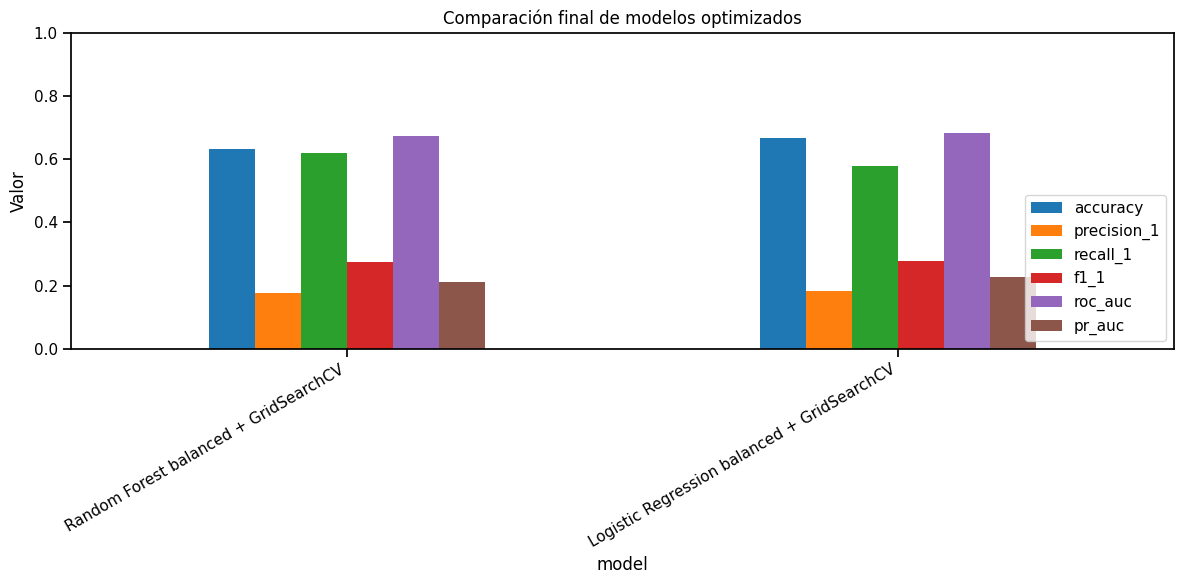

In [ ]:
metrics_to_plot = ["accuracy", "precision_1", "recall_1", "f1_1", "roc_auc", "pr_auc"]

results_plot = results_df.set_index("model")[metrics_to_plot]

ax = results_plot.plot(kind="bar", figsize=(12, 6))
ax.set_title("Comparación final de modelos optimizados")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5.7 Selección del modelo final

In [ ]:
final_model = best_logreg

### Selección del modelo final

Aunque Random Forest obtuvo un recall ligeramente superior, se seleccionó finalmente la Regresión Logística balanceada optimizada mediante GridSearchCV.

La decisión se tomó considerando varios factores:
- mejor equilibrio general entre recall, F1-score y ROC-AUC
- mayor estabilidad
- menor complejidad computacional
- una interpretabilidad mucho más adecuada para aplicaciones sanitarias

Además, al tratarse de un modelo lineal, facilita posteriormente el análisis mediante SHAP y la interpretación clínica de las predicciones.

## 5.8 Matriz de confusión del modelo final optimizado

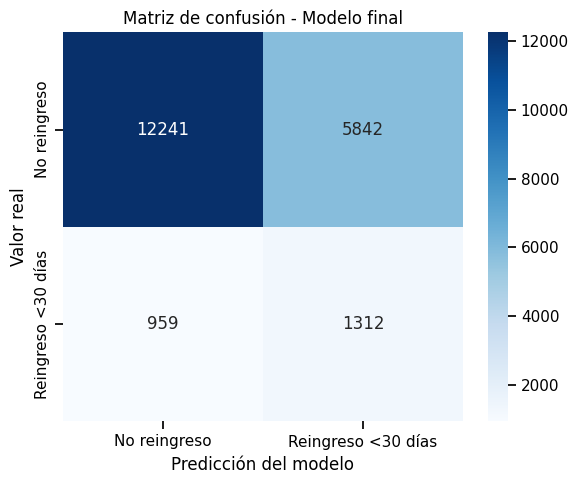

Matriz de confusión del modelo final:
[[12241  5842]
 [  959  1312]]


In [ ]:
y_pred_final = final_model.predict(X_test)

cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No reingreso", "Reingreso <30 días"],
    yticklabels=["No reingreso", "Reingreso <30 días"]
)

plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Modelo final")
plt.tight_layout()

plt.show()

print("Matriz de confusión del modelo final:")
print(cm_final)

# 6. Explicabilidad con SHAP

## 6.1 Instalación e importación

In [ ]:
!pip install shap -q

In [ ]:
import shap

## 6.2 Preparar los datos para SHAP

In [ ]:
# Extraer preprocesador y modelo ya entrenados
preprocessor_fitted = final_model.named_steps["preprocessor"]
model_fitted = final_model.named_steps["model"]

# Transformar los datos con el preprocesador entrenado
X_train_transformed = preprocessor_fitted.transform(X_train)
X_test_transformed = preprocessor_fitted.transform(X_test)

# Obtener nombres de las variables tras el One-Hot Encoding
feature_names = preprocessor_fitted.get_feature_names_out()

print("Dimensión X_train transformado:", X_train_transformed.shape)
print("Dimensión X_test transformado:", X_test_transformed.shape)
print("Número de variables tras preprocesamiento:", len(feature_names))

Dimensión X_train transformado: (81412, 2402)
Dimensión X_test transformado: (20354, 2402)
Número de variables tras preprocesamiento: 2402


## 6.3 Crear el explicador SHAP

In [ ]:
# Para regresión logística usamos LinearExplainer
explainer = shap.LinearExplainer(
    model_fitted,
    X_train_transformed
)

## 6.4 Calcular valores SHAP en una muestra del test

In [ ]:
sample_size = 1000

X_sample = X_test_transformed[:sample_size]
X_sample_original = X_test.iloc[:sample_size].copy()

shap_values = explainer.shap_values(X_sample)

print("Dimensión de los valores SHAP:", np.array(shap_values).shape)

Dimensión de los valores SHAP: (1000, 2402)


## 6.5 Importancia global de variables

/tmp/ipykernel_20075/2208862113.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


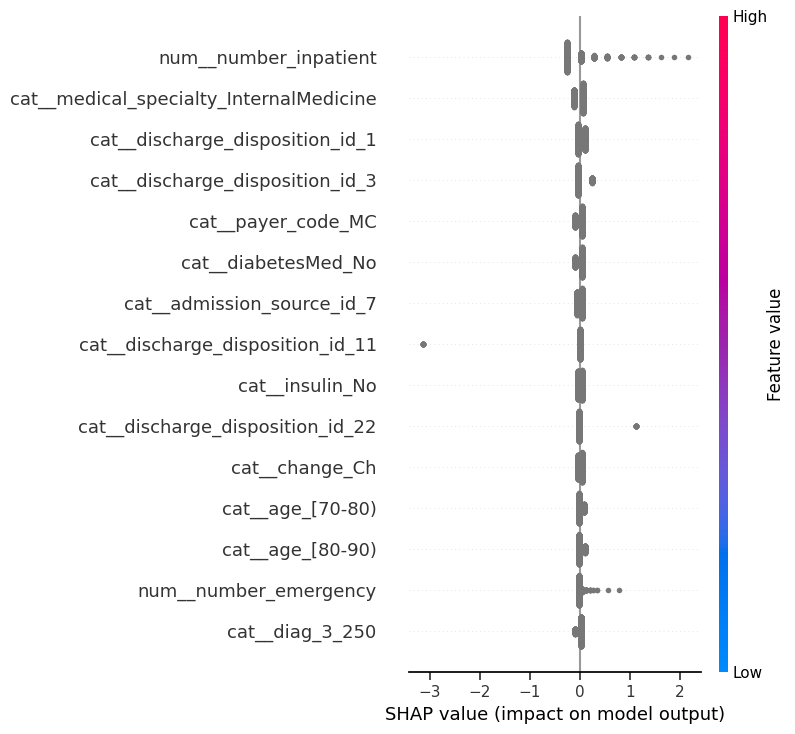

In [ ]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    max_display=15
)

### Interpretación global mediante SHAP

El análisis global mediante SHAP permitió identificar qué variables tenían mayor influencia sobre las predicciones generales del modelo.

Las variables más relevantes estuvieron relacionadas principalmente con:
- antecedentes de hospitalizaciones previas (`number_inpatient`)
- variables asociadas a medicina interna
- determinadas categorías diagnósticas
- tipos de alta hospitalaria
- variables relacionadas con el tratamiento de la diabetes

Estos resultados sugieren que el modelo aprendió patrones clínicamente coherentes con pacientes de elevada complejidad asistencial y mayor vulnerabilidad médica.

Además, observamos que algunas variables relacionadas con la medicación diabética y el uso de insulina también presentaban contribuciones relevantes sobre las predicciones. Sin embargo, es importante destacar que SHAP explica asociaciones estadísticas aprendidas por el modelo y no relaciones causales directas.

## 6.6 Explicación individual de pacientes

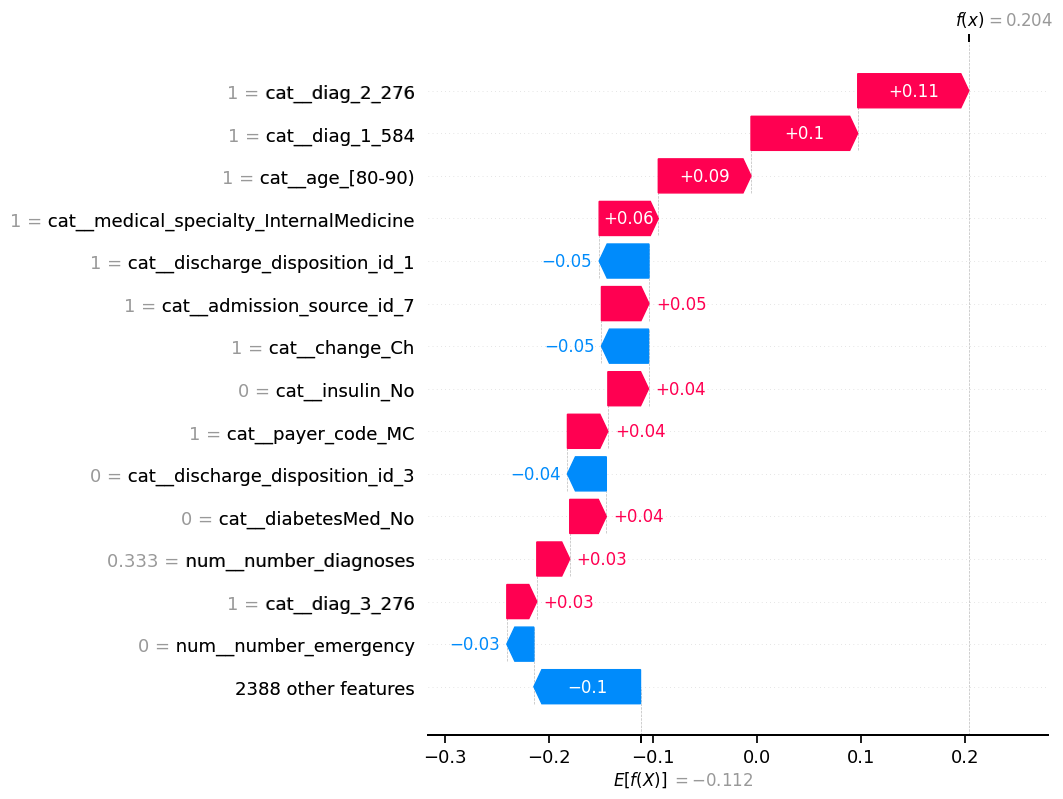

In [ ]:
# Elegimos un paciente concreto
patient_idx = 0

# Convertimos la fila sparse a array denso
x_patient_dense = X_sample[patient_idx].toarray().flatten()

# Waterfall plot individual
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[patient_idx],
        base_values=explainer.expected_value,
        data=x_patient_dense,
        feature_names=feature_names
    ),
    max_display=15
)

### Interpretación individual del paciente analizado

El gráfico waterfall muestra cómo distintas variables contribuyen positiva o negativamente sobre la probabilidad final estimada para este paciente concreto.

Las principales contribuciones positivas estuvieron relacionadas con diagnósticos clínicos específicos, edad avanzada y variables asociadas a medicina interna, lo que sugiere un perfil de elevada complejidad asistencial y vulnerabilidad clínica.

También aparecieron variables con contribución negativa, como determinadas características del alta hospitalaria o cambios en la medicación, que reducían parcialmente la probabilidad estimada de reingreso.

Sin embargo, estas contribuciones deben interpretarse con cuidado, ya que SHAP explica asociaciones estadísticas aprendidas por el modelo y no relaciones causales médicas directas.

## 6.7 Buscar un paciente realmente clasificado como alto riesgo

In [ ]:
# Probabilidades predichas
y_proba_sample = final_model.predict_proba(X_test.iloc[:sample_size])[:, 1]

# Paciente con mayor riesgo predicho
high_risk_idx = np.argmax(y_proba_sample)

print("Índice paciente alto riesgo:", high_risk_idx)
print("Probabilidad predicha:", y_proba_sample[high_risk_idx])

Índice paciente alto riesgo: 443
Probabilidad predicha: 0.8813113091337913


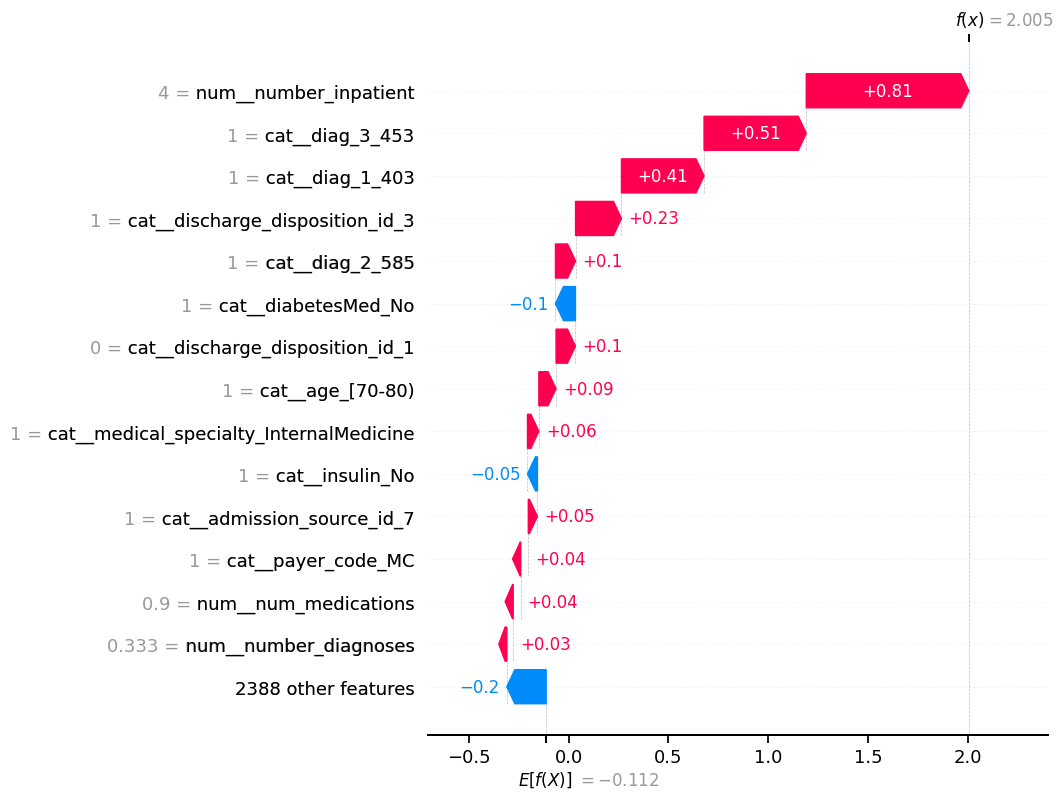

In [ ]:
# Convertimos la fila sparse a array
x_high_risk_dense = X_sample[high_risk_idx].toarray().flatten()

# Waterfall plot del paciente de mayor riesgo
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=x_high_risk_dense,
        feature_names=feature_names
    ),
    max_display=15
)

En el caso del paciente clasificado con mayor riesgo, el modelo estimó una probabilidad de reingreso temprano del 88.13%, apoyándose especialmente en el historial de ingresos hospitalarios, determinados diagnósticos clínicos y variables relacionadas con la atención en medicina interna.

También aparecieron variables con contribución negativa, como la ausencia de tratamiento con insulina o medicación diabética, que reducían parcialmente la probabilidad estimada de reingreso. Sin embargo, estas contribuciones deben interpretarse con cautela, ya que SHAP explica asociaciones estadísticas aprendidas por el modelo y no relaciones causales médicas directas.

Estas explicaciones individuales refuerzan la interpretabilidad del sistema y muestran que el modelo basa sus predicciones en patrones clínicamente plausibles, permitiendo comprender por qué un paciente es considerado de alto riesgo.

# 7. Counterfactual Explanations con DiCE


## 7.1 Instalación e importación de DiCE


In [ ]:
# Instalación e importación de DiCE
!pip install -q dice-ml

import dice_ml
import pandas as pd

print("Librería DiCE importada correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 48.1 MB/s eta 0:00:00
Librería DiCE importada correctamente.


## 7.2 Preparación de datos y modelo para DiCE

In [ ]:
# 7.2 Preparación de datos y modelo para DiCE
import dice_ml

print("Preparando datos crudos para compatibilidad con DiCE...")

# 1. Copias para no alterar los DataFrames originales del proyecto
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

# 2. Usamos las mismas listas finales del pipeline
continuous_features_dice = numeric_features
categorical_features_dice = categorical_features

print("Variables continuas usadas por DiCE:")
print(continuous_features_dice)

print("\nVariables categóricas usadas por DiCE:")
print(categorical_features_dice)

# 3. Imputación manual para que DiCE pueda trabajar sin NaN

# Numéricas: mediana calculada en train
for col in continuous_features_dice:
    median_val = X_train_clean[col].median()
    X_train_clean[col] = X_train_clean[col].fillna(median_val)
    X_test_clean[col] = X_test_clean[col].fillna(median_val)

# Categóricas: moda calculada en train
for col in categorical_features_dice:
    mode_val = X_train_clean[col].mode(dropna=True)[0]
    X_train_clean[col] = X_train_clean[col].fillna(mode_val)
    X_test_clean[col] = X_test_clean[col].fillna(mode_val)

# 4. DataFrame de entrenamiento para DiCE
df_dice_train = X_train_clean.copy()
df_dice_train["readmitted_binary"] = y_train.values

# 5. Inicializar objeto Data de DiCE
dice_data = dice_ml.Data(
    dataframe=df_dice_train,
    continuous_features=continuous_features_dice,
    outcome_name="readmitted_binary"
)

# 6. Vincular DiCE con el pipeline final de scikit-learn
dice_model = dice_ml.Model(
    model=final_model,
    backend="sklearn"
)

dice_exp = dice_ml.Dice(
    dice_data,
    dice_model,
    method="random"
)

print("\nDiCE inicializado correctamente con el modelo final.")

Preparando datos crudos para compatibilidad con DiCE...
Variables continuas usadas por DiCE:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Variables categóricas usadas por DiCE:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


/tmp/ipykernel_20075/2340321824.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_clean[col] = X_train_clean[col].fillna(mode_val)
/tmp/ipykernel_20075/2340321824.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_clean[col] = X_test_clean[col].fillna(mode_val)



DiCE inicializado correctamente con el modelo final.


### Justificación Técnica: Preparación del Entorno DiCE
Para garantizar la explicabilidad del modelo sin sufrir problemas de *data leakage* (fuga de datos), nuestro `final_model` utiliza un pipeline estricto de scikit-learn. Sin embargo, los algoritmos internos de cálculo de distancia de la librería **DiCE** no son compatibles con valores nulos (NaN) en la entrada cruda.

Para solucionar esta fricción de compatibilidad entre herramientas del estado del arte, hemos realizado una imputación paralela (mediana para numéricas, moda para categóricas) generando un subconjunto de datos "limpios" (`X_test_clean`). Esto permite a la IA generar pacientes sintéticos manteniendo el formato original y legible por humanos, interactuando de forma transparente con el pipeline subyacente.

## 7.3 Problema ético (variables no accionables)

##

In [ ]:
# Problema ético (variables no accionables)

# 1. Obtenemos las predicciones del modelo sobre los datos limpios
y_pred_final = final_model.predict(X_test_clean)

# 2. Filtramos los pacientes clasificados correctamente como ALTO RIESGO (1)
high_risk_patients = X_test_clean[y_pred_final == 1]

# 3. Seleccionamos el primer paciente como nuestro caso de estudio
paciente_cero = high_risk_patients.iloc[[0]]

print("--- Perfil del Paciente Original (ALTO RIESGO) ---")
display(paciente_cero)

print("\n--- Contrafactuales SIN restricciones (Problema Ético) ---")
try:
    # Generamos 3 escenarios para cambiar la predicción a Bajo Riesgo (0)
    # Al no usar 'features_to_vary', evidenciamos los sesgos del modelo
    cf_unrestricted = dice_exp.generate_counterfactuals(
        paciente_cero,
        total_CFs=3,
        desired_class=0
    )

    # Mostramos solo las variables que se han decidido modificar
    cf_unrestricted.visualize_as_dataframe(show_only_changes=True)

except Exception as e:
    print(f"Error en la generación: {e}")


--- Perfil del Paciente Original (ALTO RIESGO) ---


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
99195,Caucasian,Female,[80-90),1,1,7,4,MC,InternalMedicine,40,0,17,0,0,1,584,276,276,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes



--- Contrafactuales SIN restricciones (Problema Ético) ---


100%|██████████| 1/1 [00:00<00:00,  1.73it/s]

Query instance (original outcome : 1)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary
0,Caucasian,Female,[80-90),1,1,7,4,MC,InternalMedicine,40,0,17,0,0,1,584,276,276,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,1



Diverse Counterfactual set (new outcome: 0)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary
0,-,Unknown/Invalid,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Steady,-,-,-,-,-,-,-,-,-,-,-,-,-,0
1,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,540,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0
2,-,-,-,6,-,-,-,-,-,-,-,-,-,-,-,-,493,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0


### Análisis del Experimento 1: Sesgo y Atajos Algorítmicos
Al seleccionar a nuestra "Paciente Cero" (alto riesgo predicho) y solicitar a la IA que reduzca su riesgo sin ningún tipo de restricción, observamos el fenómeno del "atajo matemático".

El algoritmo sugiere alteraciones en variables de gestión burocrática, como modificar la especialidad médica (`medical_specialty` a *DCPTEAM*) o el destino al alta (`discharge_disposition_id`). Matemáticamente, el modelo ha encontrado una correlación donde ciertos servicios presentan menor tasa de reingreso. No obstante, **clínicamente este resultado es inoperable y éticamente cuestionable**, evidenciando los peligros de implementar modelos predictivos de "caja negra" sin aplicar restricciones de dominio en entornos sanitarios.

## 7.4 Apoyo a la decisión clínica (variables accionables)

In [ ]:
# Apoyo a la decisión clínica (variables accionables)

print("--- Contrafactuales ACCIONABLES (Apoyo Clínico Real) ---")

# 1. Ampliamos el arsenal clínico del médico
# Además de los días y pruebas, incluimos pautas de medicación diabética
features_accionables = [
    'time_in_hospital',   # Ajuste de los días de ingreso
    'num_medications',    # Revisión de la polimedicación
    'num_lab_procedures', # Modificación de pautas de laboratorio
    'num_procedures',     # Intervenciones médicas
    'insulin',            # Ajuste de dosis de insulina (Up, Down, Steady, No)
    'change',             # Hacer cambios en la medicación general (Ch, No)
    'diabetesMed'         # Prescripción de medicación diabética (Yes, No)
]

# 2. Si un paciente tiene un riesgo "incurable" por su edad/historial,
# pasamos al siguiente paciente de alto riesgo.
exito = False
paciente_idx = 0

while not exito and paciente_idx < len(high_risk_patients):
    paciente_estudio = high_risk_patients.iloc[[paciente_idx]]
    print(f"\nIntentando salvar al Paciente #{paciente_idx}...")

    try:
        cf_actionable = dice_exp.generate_counterfactuals(
            paciente_estudio,
            total_CFs=3,
            desired_class=0,
            features_to_vary=features_accionables
        )

        print("\n¡Éxito! La IA ha encontrado pautas clínicas para reducir el riesgo:")
        cf_actionable.visualize_as_dataframe(show_only_changes=True)
        exito = True

    except Exception as e:
        print(f"  -> Imposible reducir el riesgo solo con variables clínicas. El peso demográfico/histórico es demasiado alto.")
        paciente_idx += 1

if not exito:
    print("El modelo es tan dependiente de variables no accionables que no pudo encontrar soluciones clínicas para los pacientes probados.")

--- Contrafactuales ACCIONABLES (Apoyo Clínico Real) ---

Intentando salvar al Paciente #0...


100%|██████████| 1/1 [00:00<00:00,  3.02it/s]


¡Éxito! La IA ha encontrado pautas clínicas para reducir el riesgo:
Query instance (original outcome : 1)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary
0,Caucasian,Female,[80-90),1,1,7,4,MC,InternalMedicine,40,0,17,0,0,1,584,276,276,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,1



Diverse Counterfactual set (new outcome: 0)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary
0,-,-,-,-,-,-,-,-,-,-,6,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,No,0
1,-,-,-,-,-,-,-,-,-,117,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,No,0
2,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,No,-,-,-,-,-,-,No,0


### Análisis del Experimento 2: Apoyo a la Decisión Clínica (CDSS)
Al restringir la generación de contrafactuales estrictamente a **variables accionables por el personal médico**, el modelo demuestra haber capturado patrones clínicos complejos y se convierte en una herramienta útil de soporte. Para reducir el riesgo de reingreso de la paciente analizada, la IA propone escenarios como:

1. **Estabilización terapéutica:** Cambiar la pauta de insulina de *'Up'* (en aumento) a *'Steady'* (estable), sugiriendo que dar el alta a un paciente geriátrico con la dosis aún en ajuste es un factor crítico de riesgo.
2. **Revisión de Polifarmacia:** Reducir el número de medicamentos (`num_medications`) de 17 a 10.
3. **Prolongación de la observación:** Modificar los días de estancia (`time_in_hospital`) en combinación con la retirada de la medicación diabética específica si el cuadro clínico lo permitiese.

Estos resultados sugieren el potencial del modelo como herramienta de apoyo clínico, ya que permite generar escenarios alternativos y analizar posibles intervenciones sobre pacientes de riesgo.

Sin embargo, también observamos limitaciones importantes. Algunas recomendaciones generadas por la IA, como retirar completamente la medicación diabética o incrementar de forma extrema el número de pruebas clínicas, carecen de plausibilidad biológica o práctica real.

Este comportamiento evidencia una limitación fundamental de los modelos supervisados aplicados en medicina: el aprendizaje estadístico puede capturar correlaciones útiles para la predicción sin comprender realmente los mecanismos fisiopatológicos subyacentes.

Por ello, los sistemas de IA clínica deben interpretarse como herramientas de apoyo a la decisión y no como mecanismos automáticos de diagnóstico o intervención terapéutica. En consecuencia, resulta imprescindible mantener un enfoque Human-in-the-Loop, donde el profesional sanitario sea siempre el validador final de las recomendaciones generadas por el sistema.

## 7.5 Resumen estructurado de los contrafactuales


In [ ]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Carpetas creadas correctamente.")

Carpetas creadas correctamente.


In [ ]:
def extract_dice_counterfactuals(dice_result):
    """
    Extrae los counterfactuals generados por DiCE en formato DataFrame.
    Funciona con los objetos CounterfactualExplanations habituales de dice_ml.
    """
    cf_dfs = []

    if hasattr(dice_result, "cf_examples_list"):
        for cf_example in dice_result.cf_examples_list:
            if hasattr(cf_example, "final_cfs_df") and cf_example.final_cfs_df is not None:
                cf_dfs.append(cf_example.final_cfs_df.copy())

    if len(cf_dfs) == 0:
        raise ValueError("No se han podido extraer counterfactuals del objeto de DiCE.")

    return pd.concat(cf_dfs, ignore_index=True)

In [ ]:
cf_df = extract_dice_counterfactuals(cf_actionable)

print("Counterfactuals extraídos:")
display(cf_df)

Counterfactuals extraídos:


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary
0,Caucasian,Female,[80-90),1,1,7,4,MC,InternalMedicine,40,6,17,0,0,1,584,276,276,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,No,0
1,Caucasian,Female,[80-90),1,1,7,4,MC,InternalMedicine,117,0,17,0,0,1,584,276,276,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,No,0
2,Caucasian,Female,[80-90),1,1,7,4,MC,InternalMedicine,40,0,17,0,0,1,584,276,276,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,No,0


In [ ]:
original_patient = paciente_estudio.copy()

print("Paciente original:")
display(original_patient)

Paciente original:


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
99195,Caucasian,Female,[80-90),1,1,7,4,MC,InternalMedicine,40,0,17,0,0,1,584,276,276,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes


In [ ]:
# Probabilidad original de reingreso temprano
original_proba = final_model.predict_proba(original_patient)[:, 1][0]
original_pred = final_model.predict(original_patient)[0]

# Nos aseguramos de que cf_df tenga solo columnas usadas por el modelo
cf_features = cf_df[X_train.columns].copy()

cf_probas = final_model.predict_proba(cf_features)[:, 1]
cf_preds = final_model.predict(cf_features)

print(f"Predicción original: {original_pred}")
print(f"Probabilidad original de reingreso <30 días: {original_proba:.4f}")

cf_df_summary = cf_df.copy()
cf_df_summary["prediccion_modelo"] = cf_preds
cf_df_summary["probabilidad_readmision_30d"] = cf_probas

display(cf_df_summary)

Predicción original: 1
Probabilidad original de reingreso <30 días: 0.5508


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary,prediccion_modelo,probabilidad_readmision_30d
0,Caucasian,Female,[80-90),1,1,7,4,MC,InternalMedicine,40,6,17,0,0,1,584,276,276,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,No,0,0,0.494906
1,Caucasian,Female,[80-90),1,1,7,4,MC,InternalMedicine,117,0,17,0,0,1,584,276,276,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,No,0,0,0.496891
2,Caucasian,Female,[80-90),1,1,7,4,MC,InternalMedicine,40,0,17,0,0,1,584,276,276,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,No,0,0,0.491012


In [ ]:
def get_changed_features(original_row, cf_row, feature_columns):
    """
    Devuelve las variables que cambian entre el paciente original y un counterfactual.
    """
    changed = []

    for col in feature_columns:
        original_value = original_row.iloc[0][col]
        cf_value = cf_row[col]

        if pd.isna(original_value) and pd.isna(cf_value):
            continue

        if original_value != cf_value:
            changed.append(col)

    return changed


changed_features_list = []

for idx, row in cf_features.iterrows():
    changed = get_changed_features(original_patient, row, X_train.columns)
    changed_features_list.append(changed)

cf_df_summary["variables_modificadas"] = changed_features_list
cf_df_summary["num_variables_modificadas"] = cf_df_summary["variables_modificadas"].apply(len)

display(cf_df_summary[[
    "prediccion_modelo",
    "probabilidad_readmision_30d",
    "num_variables_modificadas",
    "variables_modificadas"
]])

,prediccion_modelo,probabilidad_readmision_30d,num_variables_modificadas,variables_modificadas
0,0,0.494906,2,"[num_procedures, diabetesMed]"
1,0,0.496891,2,"[num_lab_procedures, diabetesMed]"
2,0,0.491012,2,"[insulin, diabetesMed]"


In [ ]:
# Lista de variables clínicamente accionables o parcialmente accionables
features_accionables = [
    "time_in_hospital",
    "num_medications",
    "num_lab_procedures",
    "num_procedures",
    "insulin",
    "change",
    "diabetesMed"
]

def classify_changed_features(changed_features, actionable_features):
    accionables = [f for f in changed_features if f in actionable_features]
    no_accionables = [f for f in changed_features if f not in actionable_features]
    return accionables, no_accionables


accionables_list = []
no_accionables_list = []

for changed in cf_df_summary["variables_modificadas"]:
    acc, no_acc = classify_changed_features(changed, features_accionables)
    accionables_list.append(acc)
    no_accionables_list.append(no_acc)

cf_df_summary["variables_accionables_modificadas"] = accionables_list
cf_df_summary["variables_no_accionables_modificadas"] = no_accionables_list
cf_df_summary["num_accionables_modificadas"] = cf_df_summary["variables_accionables_modificadas"].apply(len)
cf_df_summary["num_no_accionables_modificadas"] = cf_df_summary["variables_no_accionables_modificadas"].apply(len)

display(cf_df_summary[[
    "probabilidad_readmision_30d",
    "variables_accionables_modificadas",
    "variables_no_accionables_modificadas",
    "num_accionables_modificadas",
    "num_no_accionables_modificadas"
]])

,probabilidad_readmision_30d,variables_accionables_modificadas,variables_no_accionables_modificadas,num_accionables_modificadas,num_no_accionables_modificadas
0,0.494906,"[num_procedures, diabetesMed]",[],2,0
1,0.496891,"[num_lab_procedures, diabetesMed]",[],2,0
2,0.491012,"[insulin, diabetesMed]",[],2,0


In [ ]:
dice_results_table = cf_df_summary[[
    "prediccion_modelo",
    "probabilidad_readmision_30d",
    "num_variables_modificadas",
    "variables_modificadas",
    "variables_accionables_modificadas",
    "variables_no_accionables_modificadas"
]].copy()

dice_results_table.insert(0, "counterfactual_id", range(1, len(dice_results_table) + 1))
dice_results_table["probabilidad_original_readmision_30d"] = original_proba
dice_results_table["reduccion_probabilidad"] = (
    dice_results_table["probabilidad_original_readmision_30d"]
    - dice_results_table["probabilidad_readmision_30d"]
)

display(dice_results_table)

,counterfactual_id,prediccion_modelo,probabilidad_readmision_30d,num_variables_modificadas,variables_modificadas,variables_accionables_modificadas,variables_no_accionables_modificadas,probabilidad_original_readmision_30d,reduccion_probabilidad
0,1,0,0.494906,2,"[num_procedures, diabetesMed]","[num_procedures, diabetesMed]",[],0.550809,0.055904
1,2,0,0.496891,2,"[num_lab_procedures, diabetesMed]","[num_lab_procedures, diabetesMed]",[],0.550809,0.053919
2,3,0,0.491012,2,"[insulin, diabetesMed]","[insulin, diabetesMed]",[],0.550809,0.059798


In [ ]:
dice_results_table.to_csv("results/dice_counterfactuals_summary.csv", index=False)
cf_df_summary.to_csv("results/dice_counterfactuals_full.csv", index=False)

print("Resultados de DiCE guardados en:")
print("- results/dice_counterfactuals_summary.csv")
print("- results/dice_counterfactuals_full.csv")

Resultados de DiCE guardados en:
- results/dice_counterfactuals_summary.csv
- results/dice_counterfactuals_full.csv


# 8. Privacidad diferencial

En esta sección se estudia la segunda problemática principal del proyecto: la privacidad en modelos entrenados con datos médicos sensibles.

La privacidad diferencial permite introducir ruido controlado durante el entrenamiento para reducir el riesgo de que el modelo revele información sobre pacientes concretos del conjunto de entrenamiento. El objetivo de este experimento no es superar al modelo final, sino analizar el compromiso entre privacidad y rendimiento predictivo.

Para ello se compara una regresión logística convencional con varias versiones entrenadas con privacidad diferencial, usando distintos valores de epsilon. Valores más bajos de epsilon implican mayor privacidad, pero normalmente también una mayor pérdida de rendimiento.

## 8.1 Instalación e Imports

In [ ]:
!pip install -q diffprivlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 11.0 MB/s eta 0:00:00


In [ ]:
from diffprivlib.models import LogisticRegression as DPLogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)
from sklearn.utils import resample
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

## 8.2 Selección de variables para el experimento de privacidad

In [ ]:
# Variables numéricas ya usadas en el pipeline principal
dp_numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

# Variables categóricas de baja/media cardinalidad
# Se excluyen variables de muy alta cardinalidad como diag_1, diag_2, diag_3,
# medical_specialty y payer_code para mantener el experimento manejable.
dp_categorical_features = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "insulin",
    "change",
    "diabetesMed",
    "metformin"
]

# Nos aseguramos de quedarnos solo con columnas existentes
dp_numeric_features = [col for col in dp_numeric_features if col in X_train.columns]
dp_categorical_features = [col for col in dp_categorical_features if col in X_train.columns]

dp_features = dp_numeric_features + dp_categorical_features

print("Variables numéricas usadas en el experimento DP:")
print(dp_numeric_features)

print("\nVariables categóricas usadas en el experimento DP:")
print(dp_categorical_features)

print("\nNúmero total de variables originales usadas:", len(dp_features))

Variables numéricas usadas en el experimento DP:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Variables categóricas usadas en el experimento DP:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'insulin', 'change', 'diabetesMed', 'metformin']

Número total de variables originales usadas: 18


## 8.3 Crear subconjunto de entrenamiento balanceado

Como el dataset está muy desbalanceado, entrenaremos los modelos de este experimento sobre un subconjunto balanceado del entrenamiento. La evaluación seguirá haciéndose sobre el test original.

In [ ]:
# Unimos X_train e y_train para hacer undersampling solo en train
train_dp = X_train[dp_features].copy()
train_dp["target"] = y_train.values

train_majority = train_dp[train_dp["target"] == 0]
train_minority = train_dp[train_dp["target"] == 1]

print("Clase mayoritaria en train:", train_majority.shape[0])
print("Clase minoritaria en train:", train_minority.shape[0])

# Undersampling de la clase mayoritaria para balancear
train_majority_downsampled = resample(
    train_majority,
    replace=False,
    n_samples=len(train_minority),
    random_state=SEED
)

train_dp_balanced = pd.concat([train_majority_downsampled, train_minority])
train_dp_balanced = train_dp_balanced.sample(frac=1, random_state=SEED).reset_index(drop=True)

X_train_dp = train_dp_balanced.drop(columns=["target"])
y_train_dp = train_dp_balanced["target"]

X_test_dp = X_test[dp_features].copy()
y_test_dp = y_test.copy()

print("\nDistribución del target en entrenamiento DP:")
print(y_train_dp.value_counts(normalize=True).round(3))

print("\nShape X_train_dp:", X_train_dp.shape)
print("Shape X_test_dp:", X_test_dp.shape)

Clase mayoritaria en train: 72326
Clase minoritaria en train: 9086

Distribución del target en entrenamiento DP:
target
0    0.5
1    0.5
Name: proportion, dtype: float64

Shape X_train_dp: (18172, 18)
Shape X_test_dp: (20354, 18)


## 8.4 Preprocesamiento específico para privacidad diferencial

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Compatibilidad entre versiones de scikit-learn
try:
    onehot_dp = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_dp = OneHotEncoder(handle_unknown="ignore", sparse=False)

dp_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

dp_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot_dp)
])

dp_preprocessor = ColumnTransformer(
    transformers=[
        ("num", dp_numeric_transformer, dp_numeric_features),
        ("cat", dp_categorical_transformer, dp_categorical_features)
    ]
)

X_train_dp_processed = dp_preprocessor.fit_transform(X_train_dp)
X_test_dp_processed = dp_preprocessor.transform(X_test_dp)

print("Shape train procesado:", X_train_dp_processed.shape)
print("Shape test procesado:", X_test_dp_processed.shape)

Shape train procesado: (18172, 83)
Shape test procesado: (20354, 83)


## 8.5 Acotación de la norma de los datos

La privacidad diferencial necesita controlar la sensibilidad de los datos. Para ello se acota la norma L2 de las muestras.

In [ ]:
def clip_by_l2_norm(X, max_norm):
    """
    Acota cada fila de X para que su norma L2 no supere max_norm.
    """
    norms = np.linalg.norm(X, axis=1)
    scale = np.minimum(1, max_norm / (norms + 1e-12))
    return X * scale[:, np.newaxis]


MAX_NORM = 10.0

X_train_dp_clipped = clip_by_l2_norm(X_train_dp_processed, MAX_NORM)
X_test_dp_clipped = clip_by_l2_norm(X_test_dp_processed, MAX_NORM)

print("Norma máxima en train tras clipping:", np.linalg.norm(X_train_dp_clipped, axis=1).max())
print("Norma máxima en test tras clipping:", np.linalg.norm(X_test_dp_clipped, axis=1).max())

Norma máxima en train tras clipping: 9.999999999999844
Norma máxima en test tras clipping: 9.999999999999762


## 8.6 Función común de evaluación

In [ ]:
def evaluate_binary_model(model, X_eval, y_eval, model_name):
    """
    Evalúa un modelo binario con métricas adecuadas para datos desbalanceados.
    """
    y_pred = model.predict(X_eval)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_eval)[:, 1]
    else:
        y_proba = y_pred

    results = {
        "modelo": model_name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, y_proba),
        "pr_auc": average_precision_score(y_eval, y_proba)
    }

    return results

## 8.7 Modelo normal comparable

In [ ]:
normal_lr_dp = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

normal_lr_dp.fit(X_train_dp_clipped, y_train_dp)

normal_results = evaluate_binary_model(
    normal_lr_dp,
    X_test_dp_clipped,
    y_test_dp,
    "Logistic Regression sin DP"
)

normal_results

{'modelo': 'Logistic Regression sin DP',
 'accuracy': 0.6653728996757394,
 'precision': 0.18216185942313076,
 'recall': 0.5728753852928226,
 'f1': 0.27642621905874853,
 'roc_auc': np.float64(0.676008662341827),
 'pr_auc': np.float64(0.21927623137015875)}

## 8.8 Modelos con privacidad diferencial

In [ ]:
epsilons = [0.1, 1.0, 10.0]
dp_results = []

for eps in epsilons:
    print(f"Entrenando modelo con privacidad diferencial, epsilon={eps}...")

    dp_model = DPLogisticRegression(
        epsilon=eps,
        data_norm=MAX_NORM,
        max_iter=1000,
        random_state=SEED
    )

    dp_model.fit(X_train_dp_clipped, y_train_dp)

    result = evaluate_binary_model(
        dp_model,
        X_test_dp_clipped,
        y_test_dp,
        f"Logistic Regression DP ε={eps}"
    )

    dp_results.append(result)

print("Entrenamiento DP finalizado.")

Entrenando modelo con privacidad diferencial, epsilon=0.1...
Entrenando modelo con privacidad diferencial, epsilon=1.0...
Entrenando modelo con privacidad diferencial, epsilon=10.0...
Entrenamiento DP finalizado.


In [ ]:
# Tabla comparativa de privacidad diferencial
privacy_results_df = pd.DataFrame([normal_results] + dp_results)

display(
    privacy_results_df.style.format({
        "accuracy": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}"
    })
)

privacy_results_df.to_csv("results/differential_privacy_results.csv", index=False)

print("Resultados guardados en results/differential_privacy_results.csv")

,modelo,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression sin DP,0.6654,0.1822,0.5729,0.2764,0.6760,0.2193
1,Logistic Regression DP ε=0.1,0.5672,0.1262,0.4861,0.2004,0.5385,0.1252
2,Logistic Regression DP ε=1.0,0.5656,0.1339,0.5288,0.2136,0.5695,0.1419
3,Logistic Regression DP ε=10.0,0.6610,0.1763,0.5553,0.2677,0.6631,0.1969


Resultados guardados en results/differential_privacy_results.csv


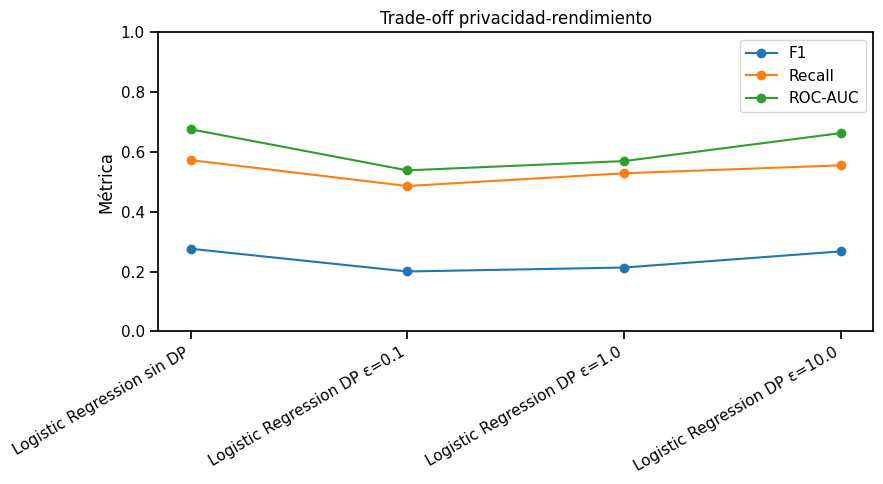

In [ ]:
# Visualización del trade-off privacidad-rendimiento
plot_df = privacy_results_df.copy()

plt.figure(figsize=(9, 5))
plt.plot(plot_df["modelo"], plot_df["f1"], marker="o", label="F1")
plt.plot(plot_df["modelo"], plot_df["recall"], marker="o", label="Recall")
plt.plot(plot_df["modelo"], plot_df["roc_auc"], marker="o", label="ROC-AUC")
plt.xticks(rotation=30, ha="right")
plt.title("Trade-off privacidad-rendimiento")
plt.ylabel("Métrica")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig("figures/privacy_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

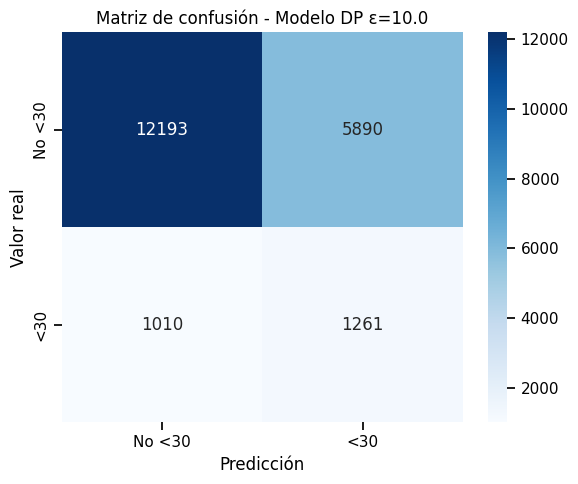

              precision    recall  f1-score   support

           0       0.92      0.67      0.78     18083
           1       0.18      0.56      0.27      2271

    accuracy                           0.66     20354
   macro avg       0.55      0.61      0.52     20354
weighted avg       0.84      0.66      0.72     20354



In [ ]:
# Matriz de confusión del mejor modelo DP
# Elegimos como referencia el modelo DP con mayor epsilon, normalmente el menos restrictivo
best_eps = 10.0

best_dp_model = DPLogisticRegression(
    epsilon=best_eps,
    data_norm=MAX_NORM,
    max_iter=1000,
    random_state=SEED
)

best_dp_model.fit(X_train_dp_clipped, y_train_dp)

y_pred_best_dp = best_dp_model.predict(X_test_dp_clipped)

cm_dp = confusion_matrix(y_test_dp, y_pred_best_dp)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_dp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No <30", "<30"],
    yticklabels=["No <30", "<30"]
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title(f"Matriz de confusión - Modelo DP ε={best_eps}")
plt.tight_layout()
plt.savefig("figures/confusion_matrix_dp.png", dpi=300, bbox_inches="tight")
plt.show()

print(classification_report(y_test_dp, y_pred_best_dp, zero_division=0))

### Conclusión de privacidad diferencial

El experimento muestra el compromiso entre privacidad y rendimiento predictivo. El modelo sin privacidad diferencial alcanza el mejor rendimiento general, con un ROC-AUC de 0.6760, un recall de 0.5729 y un F1-score de 0.2764.

Al aplicar privacidad diferencial, el rendimiento disminuye, especialmente con valores bajos de epsilon. Para epsilon = 0.1, el modelo presenta una caída clara en todas las métricas, con un ROC-AUC de 0.5385 y un F1-score de 0.2004. Esto refleja el efecto del mayor nivel de privacidad, que introduce más ruido en el entrenamiento y reduce la capacidad predictiva.

A medida que aumenta epsilon, la restricción de privacidad se relaja y el rendimiento mejora. Con epsilon = 10.0, el modelo obtiene resultados cercanos al modelo sin privacidad diferencial, con un ROC-AUC de 0.6631, un recall de 0.5553 y un F1-score de 0.2677.

Vemos que los resultados son coherentes con el comportamiento esperado de la privacidad diferencial: mayor privacidad implica una mayor pérdida de utilidad predictiva, mientras que valores más altos de epsilon permiten recuperar rendimiento a costa de reducir la protección ofrecida. En un contexto sanitario, este equilibrio debe analizarse cuidadosamente, ya que el modelo trabaja con datos sensibles y las decisiones pueden afectar al seguimiento clínico de los pacientes.